In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import json
with open("config.json") as f:
    config = json.load(f)

In [2]:
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df.columns

Index(['subject', 'session', 'task', 'run', 'age', 'sex', 'drug_admin_time',
       'ppl_time', 'sdi_time', 'scan_start_time', 'scan_end_time',
       'scan_min_since_admin', 'ppl_min_since_admin', 'sdi_min_since_admin',
       'ppl_min_since_scan', 'sdi_min_since_scan', 'PPL_mcg/L', 'SDI',
       'time_interval', 'tr', 'te', 'num_vols', 'ped', 'coil_name',
       'coil_active', 'scanner', 'include_scan_coil_numvols',
       'include_manual_qc', 'ratio_outliers_fd0.5_std_dvars1000', 'mean_fd',
       'mean_std_dvars', 'max_fd', 'outlier_locs', 'scan_filename',
       'preproc_filename_volumetric', 'preproc_filename_cifti',
       'preproc_filename_cifti_despiked', 'preproc_filename_cifti_aroma'],
      dtype='object')

In [3]:
# filter out rows where include_scan is due to missing head coil or interrupted scan
df = df[df['include_scan_coil_numvols']]
df = df[df['include_manual_qc']]
# for the purpose of visualization, set negative values of scan_min_since_admin to 0
df['scan_min_since_admin'] = df['scan_min_since_admin'].clip(lower=0)
# make a new column where subjects get new names, e.g., Subject 1, Subject 2, etc.
df['subject_clean'] = df['subject'].astype('category')
df['subject_clean'] = df['subject_clean'].cat.rename_categories(['Subject {}'.format(i) for i in range(1, len(df['subject_clean'].cat.categories) + 1)])

## Line plots of the acute psilocybin experience
These plots only contain measurements with an associated included rs-fmri scan

In [4]:
subjects = df['subject_clean'].unique()
markers = {subject: 'o' for subject in subjects}

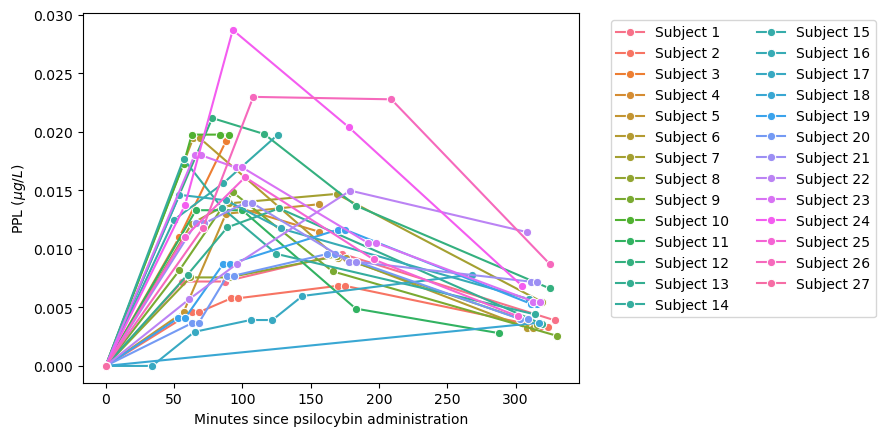

In [5]:
sns.lineplot(data=df, x='scan_min_since_admin', y='PPL_mcg/L', hue='subject_clean', style='subject_clean', markers=markers, dashes=False)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.xlabel('Minutes since psilocybin administration')
plt.ylabel(r'PPL ($\mu g/L$)');

Text(0, 0.5, 'Subject drug intensity (SDI)')

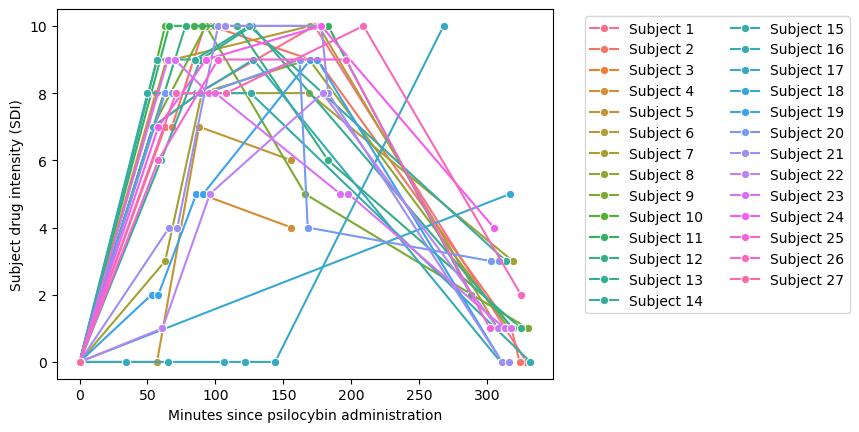

In [6]:
sns.lineplot(data=df, x='scan_min_since_admin', y='SDI', hue='subject_clean', style='subject_clean', markers=markers, dashes=False)
# legend outside
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.xlabel('Minutes since psilocybin administration')
plt.ylabel('Subject drug intensity (SDI)')

Count the number of subjects with a scan at 0min, 20-80min, 80-150min, 150-270min, 270+min

In [ ]:
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df['scan_min_since_admin'] = df['scan_min_since_admin'].clip(lower=0)

In [23]:
bins = [-1, 20, 80, 150, 270, np.inf]
df['time_bin'] = pd.cut(df['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])
subject_counts = df.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df)))

     Time Bin  Number of Subjects
0     0-20min                  28
1    20-80min                  27
2   80-150min                  27
3  150-270min                  21
4     270+min                  23
       Total number of scans: 170


In [24]:
bins = [-1, 20, 80, 150, 270, np.inf]
df2 = df[df['include_scan_coil_numvols']]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

     Time Bin  Number of Subjects
0     0-20min                  28
1    20-80min                  27
2   80-150min                  27
3  150-270min                  19
4     270+min                  23
       Total number of scans: 165


/tmp/ipykernel_43767/3776898103.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])


In [25]:
bins = [-1, 20, 80, 150, 270, np.inf]
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

     Time Bin  Number of Subjects
0     0-20min                  26
1    20-80min                  24
2   80-150min                  24
3  150-270min                  19
4     270+min                  21
       Total number of scans: 153


In [26]:
bins = [-1, 20, 80, 150, 270, np.inf]
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2 = df2[df2['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
# df2 = df2[df2['max_fd'] < config["scan_max_fd_threshold"]]
# df2 = df[df['ratio_outliers_fd0.5_std_dvars1.5'] < 0.15]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

     Time Bin  Number of Subjects
0     0-20min                  26
1    20-80min                  21
2   80-150min                  20
3  150-270min                  18
4     270+min                  21
       Total number of scans: 142


In [32]:
bins = [-1, 20, 80, 150, 270, np.inf]
df2 = df[df['include_scan_coil_numvols']]
df2 = df2[df2['include_manual_qc']]
df2 = df2[df2['ratio_outliers_fd0.5_std_dvars1000'] < config["max_ratio_outliers_fd0.5_std_dvars1000"]]
df2 = df2[df2['max_fd'] < config["scan_max_fd_threshold"]]
# df2 = df[df['ratio_outliers_fd0.5_std_dvars1.5'] < 0.15]
df2['time_bin'] = pd.cut(df2['scan_min_since_admin'], bins=bins, labels=['0-20min', '20-80min', '80-150min', '150-270min', '270+min'])
subject_counts = df2.groupby('time_bin')['subject'].nunique().reset_index()
subject_counts.columns = ['Time Bin', 'Number of Subjects']
print(subject_counts)
print('       Total number of scans: '+str(len(df2)))

     Time Bin  Number of Subjects
0     0-20min                  26
1    20-80min                  18
2   80-150min                  17
3  150-270min                  14
4     270+min                  20
       Total number of scans: 125
